# Probabilistic Day-Ahead Electricity Load Forecasting

**Spectral structure, transparent benchmarks and calibration on Belgian grid data.**

Electricity demand is strongly periodic, but periodicity is not the same as
predictability. This study asks how much of Belgian quarter-hourly load can be
forecast one day ahead from temporal structure alone, and whether the resulting
uncertainty estimates are statistically calibrated.

Before building anything, increment 1 audits what is already in the data: Elia
publishes an operational day-ahead forecast with P10/P90 bounds. That is a
professional reference — and a calibration question in its own right.

Companion study: [ElectricityResourceAdequacy](https://github.com/evrelegh/ElectricityResourceAdequacy)
— the same Fourier transform, used to convolve random variables rather than to
decompose temporal structure.

*Increment 1 — cells 01–05: acquisition, integrity, Elia audit, first figures.
No forecasting model yet.*


In [1]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 01 · §0 · Forecast contract & configuration                    v1.1.0
# provides ▸ np · pd · plt · requests · elf.* · ELIA_BASE · ZONE · YEARS
#            TZ · H_ALIGN · FREQ · ORIGIN_CIVIL_HOUR · CACHE · RNG · DS_LOAD
# requires ▸ —
# ══════════════════════════════════════════════════════════════════════════
import warnings, os, pathlib
from io import StringIO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

# Extracted core — general behaviour lives in the package and is unit
# tested there; the notebook keeps the narrative and the data contracts.
from electricity_load_forecasting.calendar import (
    be_holidays, civil_features, easter, expected_slots)
from electricity_load_forecasting.metrics import (
    coverage, interval_width, pinball, score, score_point, score_prob)
from electricity_load_forecasting.spectral import (
    dominant_periods, fill_short_gaps, periodogram)

warnings.filterwarnings("ignore", message='Creating legend with loc="best"')

# --- zone & analysis window -------------------------------------------------
ZONE  = "BE"
YEARS = [2023]                       # multi-year capable; widen once v1 runs
START = pd.Timestamp(f"{min(YEARS)}-01-01")    # civil analysis window
END   = pd.Timestamp(f"{max(YEARS)}-12-31")
# Belgium is UTC+1/+2, so a UTC calendar year is not a civil year: pull with a
# month of margin either side and trim to complete civil days in CELL 03.
FETCH_START = (START - pd.offsets.MonthBegin(1)).strftime("%Y-%m-%d")
FETCH_END   = (END   + pd.offsets.MonthEnd(1)).strftime("%Y-%m-%d")

# --- the forecast contract --------------------------------------------------
# Fixed daily origin; target is the next civil day at quarter-hour resolution.
# Every feature for target T+h must be available at T. Enforced in CELL 07.
# Target is the FULL next Belgian civil day, so the number of horizons is a
# property of the calendar, not a constant: H_D = 92 / 96 / 100 at the DST
# transitions. H_ALIGN is only for horizon-resolved reporting, where the two
# odd days are excluded so every h carries the same sample size.
H_ALIGN = 96
FREQ    = "15min"
TZ   = "Europe/Brussels"             # civil time — calendar features only
                                     # UTC stays the computational time axis
# ASSUMPTION (to confirm against Elia metadata, not chosen post hoc):
# ods001 `dayaheadforecast` is published ahead of the day-ahead market gate.
# Treated here as issued at 12:00 civil time on D-1 for the whole of day D.
ORIGIN_CIVIL_HOUR = 12

# --- data endpoints ---------------------------------------------------------
ELIA_BASE = "https://opendata.elia.be/api/explore/v2.1"   # Opendatasoft, no token
DS_LOAD   = "ods001"                                      # measured + forecast load, BE

CACHE = pathlib.Path("cache"); CACHE.mkdir(exist_ok=True)
RNG   = np.random.default_rng(7)

print(f"zone={ZONE}  civil={START:%Y-%m-%d}..{END:%Y-%m-%d}  fetch={FETCH_START}..{FETCH_END}  H_align={H_ALIGN}  tz={TZ}")


Matplotlib is building the font cache; this may take a moment.


zone=BE  civil=2023-01-01..2023-12-31  fetch=2022-12-01..2024-01-31  H_align=96  tz=Europe/Brussels


In [2]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 02 · §1 · Elia open-data client + cached pull                  v1.1.0
# provides ▸ elia_catalog · elia_peek · elia_fetch · _csv · LOAD
# requires ▸ requests · pd · ELIA_BASE · DS_LOAD · FETCH_START · FETCH_END · CACHE
# ══════════════════════════════════════════════════════════════════════════
# Client carried over unchanged from ElectricityResourceAdequacy CELL 02.
from time import sleep

def elia_catalog(query, limit=8):
    """List Elia datasets whose metadata matches `query` (id + title)."""
    r = requests.get(f"{ELIA_BASE}/catalog/datasets",
                     params={"where": f'"{query}"', "limit": limit}, timeout=30)
    r.raise_for_status()
    return pd.DataFrame([{"dataset_id": d["dataset_id"],
                          "title": d.get("metas", {}).get("default", {}).get("title", "")}
                         for d in r.json().get("results", [])])

def elia_peek(dataset_id, limit=5):
    """A few records to reveal the field names / schema (fast, no bulk)."""
    r = requests.get(f"{ELIA_BASE}/catalog/datasets/{dataset_id}/records",
                     params={"limit": limit}, timeout=30)
    r.raise_for_status()
    return pd.json_normalize(r.json().get("results", []))

def _csv(dataset_id, where="", order_by="", tries=4):
    """One streamed CSV-export request, retried on a dropped connection."""
    params = {k: v for k, v in dict(where=where, order_by=order_by).items() if v}
    url = f"{ELIA_BASE}/catalog/datasets/{dataset_id}/exports/csv"
    for a in range(1, tries + 1):
        try:
            with requests.get(url, params=params, timeout=300, stream=True) as r:
                r.raise_for_status()
                buf = StringIO()
                for chunk in r.iter_content(chunk_size=1 << 16, decode_unicode=True):
                    if chunk:
                        buf.write(chunk)
            buf.seek(0)
            return pd.read_csv(buf, sep=";")
        except (requests.exceptions.ChunkedEncodingError,
                requests.exceptions.ConnectionError,
                requests.exceptions.Timeout) as e:
            if a == tries:
                raise
            print(f"    {dataset_id}: {type(e).__name__} — retry {a}/{tries}")
            sleep(2 * a)

def elia_fetch(dataset_id, start, end):
    """Full series over [start, end], pulled MONTH BY MONTH and concatenated —
    small requests that survive where one giant export drops. Time field auto-detected."""
    cols = list(elia_peek(dataset_id, 1).columns)
    ts = next((c for c in cols if "datetime" in c.lower()
               or c.lower() in ("date", "timestamp")), None)
    if ts is None:
        raise ValueError(f"{dataset_id}: no time field in {cols}")
    edges = pd.date_range(pd.Timestamp(start).replace(day=1),
                          pd.Timestamp(end) + pd.offsets.MonthBegin(1), freq="MS")
    parts = []
    for lo, hi in zip(edges[:-1], edges[1:]):
        w = f"{ts} >= '{lo:%Y-%m-%d}' AND {ts} < '{hi:%Y-%m-%d}'"
        d = _csv(dataset_id, where=w, order_by=ts)
        print(f"    {dataset_id} {lo:%Y-%m}: {len(d):6d} rows")
        parts.append(d)
    return pd.concat(parts, ignore_index=True)

# --- cached acquisition -----------------------------------------------------
def cached_fetch(dataset_id, start, end, refresh=False):
    """Pull once, reuse thereafter. Raw payload only — no transformation here."""
    f = CACHE / f"{dataset_id}_{start}_{end}.csv.gz"
    if f.exists() and not refresh:
        print(f"cache hit  {f.name}")
        return pd.read_csv(f)
    df = elia_fetch(dataset_id, start, end)
    df.to_csv(f, index=False, compression="gzip")
    print(f"cached     {f.name}  {df.shape}")
    return df

print(f"--- {DS_LOAD} columns ---")
print(list(elia_peek(DS_LOAD).columns))

LOAD = cached_fetch(DS_LOAD, FETCH_START, FETCH_END)
print(f"\nLOAD: {LOAD.shape}")
print(LOAD.head(3).to_string(index=False))


--- ods001 columns ---
['datetime', 'resolutioncode', 'totalload', 'mostrecentforecast', 'mostrecentconfidence10', 'mostrecentconfidence90', 'dayaheadforecast', 'dayaheadconfidence10', 'dayaheadconfidence90', 'weekaheadforecast']
    ods001 2022-12:   2976 rows
    ods001 2023-01:   2976 rows
    ods001 2023-02:   2688 rows
    ods001 2023-03:   2976 rows
    ods001 2023-04:   2880 rows
    ods001 2023-05:   2976 rows
    ods001 2023-06:   2880 rows
    ods001 2023-07:   2976 rows
    ods001 2023-08:   2976 rows
    ods001 2023-09:   2880 rows
    ods001 2023-10:   2976 rows
    ods001 2023-11:   2880 rows
    ods001 2023-12:   2976 rows
    ods001 2024-01:   2976 rows
cached     ods001_2022-12-01_2024-01-31.csv.gz  (40992, 10)

LOAD: (40992, 10)
                 datetime resolutioncode  totalload  mostrecentforecast  mostrecentconfidence10  mostrecentconfidence90  dayaheadforecast  dayaheadconfidence10  dayaheadconfidence90  weekaheadforecast
2022-12-01T00:00:00+00:00          PT15M  

In [3]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 03 · §1 · Data integrity — hard gate on the time axis          v1.1.0
# provides ▸ L · HOL
# requires ▸ LOAD · pd · np · TZ · FREQ · START · END
# ══════════════════════════════════════════════════════════════════════════
# Nothing downstream is trusted unless this cell passes. Failures raise.

FIELDS = {"y": "totalload", "yhat_da": "dayaheadforecast",
          "q10_da": "dayaheadconfidence10", "q90_da": "dayaheadconfidence90"}

missing = [c for c in FIELDS.values() if c not in LOAD.columns]
assert not missing, f"ods001 missing expected fields: {missing}\ngot: {list(LOAD.columns)}"

L = (LOAD.assign(datetime=pd.to_datetime(LOAD["datetime"], utc=True))
         .rename(columns={v: k for k, v in FIELDS.items()})
         [["datetime", *FIELDS.keys()]]
         .sort_values("datetime").reset_index(drop=True))

# --- time-axis gate ---------------------------------------------------------
assert L["datetime"].is_unique, (
    f"duplicate timestamps: {int(L['datetime'].duplicated().sum())} — "
    "check ods001 for a resolutioncode/region split")
assert L["datetime"].is_monotonic_increasing, "timestamps not sorted"

# Uniform spacing on the UTC axis is the strong gate: it makes the series a
# contiguous grid, and tz_convert only relabels it. A missing quarter shows up
# here as a 30-min step, so no separate civil-grid test is needed downstream.
gaps = L["datetime"].diff().dropna()
bad_gap = gaps[gaps != pd.Timedelta(FREQ)]
assert bad_gap.empty, (
    f"irregular spacing on the UTC axis — {len(bad_gap)} step(s), "
    f"sizes {sorted(set(bad_gap))[:5]}, first at "
    f"{L.loc[bad_gap.index[0], 'datetime']}")

# --- civil-time calendar features ------------------------------------------
# easter / be_holidays / expected_slots now live in the package: general
# behaviour, tested in tests/test_calendar.py rather than asserted here.
civ = L["datetime"].dt.tz_convert(TZ)
L["civil_date"] = civ.dt.normalize().dt.tz_localize(None)
L["qod"]        = civ.dt.hour * 4 + civ.dt.minute // 15      # 0..95, civil clock
L["hour"]       = civ.dt.hour
L["dow"]        = civ.dt.dayofweek
L["month"]      = civ.dt.month
L["is_weekend"] = L["dow"] >= 5

# --- trim to complete civil days inside the analysis window ----------------
# A civil day is 96 quarters except at the DST transitions (92 / 100). Length
# is derived from the zone itself, not asserted. Partial days at the fetch
# boundary are dropped: a 96-quarter lag across them would be silently wrong.
L = L[L["civil_date"].between(START, END)].copy()
per_day = L.groupby("civil_date").size()
exp = per_day.index.to_series().map(lambda d: expected_slots(d, TZ, FREQ))
incomplete = per_day[per_day != exp]
if len(incomplete):
    print("dropped incomplete civil days:",
          dict(zip(incomplete.index.strftime("%Y-%m-%d"), incomplete.values)))
L = L[~L["civil_date"].isin(incomplete.index)].reset_index(drop=True)

per_day = L.groupby("civil_date").size()
exp = per_day.index.to_series().map(lambda d: expected_slots(d, TZ, FREQ))
assert (per_day == exp).all(), f"incomplete civil days remain:\n{per_day[per_day != exp]}"
assert L["qod"].between(0, 95).all(), "quarter-of-day outside 0..95"
dst = per_day[per_day != 96]
print(f"complete civil days: {len(per_day)}  slots: {len(L)}")
print("DST days:", dict(zip(dst.index.strftime("%Y-%m-%d"), dst.values)) or "none")

HOL = be_holidays(sorted({*L["civil_date"].dt.year}))
L["is_holiday"] = L["civil_date"].isin(HOL)

# --- published quantile ordering -------------------------------------------
band = L.dropna(subset=["q10_da", "q90_da"])
bad = int((band["q10_da"] > band["q90_da"]).sum())
assert bad == 0, f"{bad} slots with published P10 > P90"

# --- missingness, reported not silently dropped -----------------------------
print("\nmissing per field:")
print(L[list(FIELDS)].isna().sum().to_string())
print(f"\nL: {L.shape}  {L['datetime'].min()} .. {L['datetime'].max()}")
print(f"holidays in window: {len(HOL[(HOL >= L['civil_date'].min()) & (HOL <= L['civil_date'].max())])}")


complete civil days: 365  slots: 35040
DST days: {'2023-03-26': np.int64(92), '2023-10-29': np.int64(100)}

missing per field:
y          3
yhat_da    0
q10_da     0
q90_da     0

L: (35040, 12)  2022-12-31 23:00:00+00:00 .. 2023-12-31 22:45:00+00:00
holidays in window: 10


In [4]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 04 · §2 · Elia day-ahead audit — accuracy and calibration      v1.1.0
# provides ▸ A · elia_overall · common · by_hour · by_month · by_daytype
# requires ▸ L · pd · np
# ══════════════════════════════════════════════════════════════════════════
# No model of our own yet. What does the operational forecast already deliver?
# Scoring functions come from the package; only the dataset-specific
# assumptions and stratifiers belong here.

# ASSUMPTION (to confirm against Elia metadata, as with the forecast origin):
# `dayaheadconfidence10/90` are treated here as the 10th and 90th percentiles
# of Elia's predictive distribution, hence a nominal 80% central interval.
A = L.dropna(subset=["y", "yhat_da"]).copy()
A["e"] = A["y"] - A["yhat_da"]
A["inside"] = (A["y"] >= A["q10_da"]) & (A["y"] <= A["q90_da"])

# Ex-post diagnostic stratifier: realised load is not available at forecast
# time, so this is for reading the error, never a feature. The forecast-load
# decile is the ex-ante operational counterpart.
A["realised_load_decile"] = pd.qcut(A["y"], 10, labels=False, duplicates="drop")
A["forecast_load_decile"] = pd.qcut(A["yhat_da"], 10, labels=False, duplicates="drop")
A["daytype"] = np.where(A["is_holiday"], "holiday",
                np.where(A["is_weekend"], "weekend", "working day"))

elia_overall = score(A)
print("Elia day-ahead — overall")
print(elia_overall.round(3).to_string())
print(f"\nnominal P10-P90 coverage = 0.80  ·  realised = {elia_overall['cov']:.3f}")

# Same metrics restricted to the common sample, so any population difference
# between the point and probabilistic figures above is visible, not implicit.
common = A.dropna(subset=["y", "yhat_da", "q10_da", "q90_da"])
if len(common) != int(elia_overall["n_point"]):
    print(f"\npoint sample {int(elia_overall['n_point'])} vs common sample {len(common)}"
          f" — point metrics on the common sample:")
    print(score_point(common).round(3).to_string())
else:
    print("\npoint and probabilistic samples coincide")

def by(key, label=None):
    t = A.groupby(key).apply(score).round(3)
    print(f"\n--- by {label or key} ---")
    print(t.to_string())
    return t

by_hour    = by("hour", "hour of civil day")
by_month   = by("month")
by_daytype = by("daytype", "day type")
by_rdecile = by("realised_load_decile", "realised-load decile (ex post)")
by_fdecile = by("forecast_load_decile", "forecast-load decile (ex ante)")

# Conditional coverage is where an overall 80% can hide an operational problem.
print("\n--- P10-P90 coverage, worst 8 hour x season cells ---")
A["season"] = A["month"].map({12: "DJF", 1: "DJF", 2: "DJF", 3: "MAM", 4: "MAM", 5: "MAM",
                              6: "JJA", 7: "JJA", 8: "JJA", 9: "SON", 10: "SON", 11: "SON"})
cc = (A.groupby(["season", "hour"])
        .agg(cov=("inside", "mean"), n=("inside", "size")).reset_index())
print(cc.nsmallest(8, "cov").round(3).to_string(index=False))


Elia day-ahead — overall
n_point     35037.000
bias          -59.860
MAE           259.865
RMSE          341.957
n_prob      35037.000
cov             0.721
width         745.847
pin_lo         65.530
pin_hi         61.885
pin_mean       63.708

nominal P10-P90 coverage = 0.80  ·  realised = 0.721

point and probabilistic samples coincide

--- by hour of civil day ---
      n_point     bias      MAE     RMSE  n_prob    cov    width  pin_lo  pin_hi  pin_mean
hour                                                                                      
0      1460.0 -104.182  230.530  298.317  1460.0  0.801  753.914  54.804  54.052    54.428
1      1460.0  -83.513  222.706  297.914  1460.0  0.771  723.958  58.044  53.034    55.539
2      1460.0  -77.266  217.158  302.651  1460.0  0.751  685.801  61.899  52.944    57.422
3      1460.0  -72.716  216.179  301.979  1460.0  0.753  684.099  61.083  52.713    56.898
4      1460.0  -76.371  217.381  305.217  1460.0  0.758  684.110  61.254  53.850   

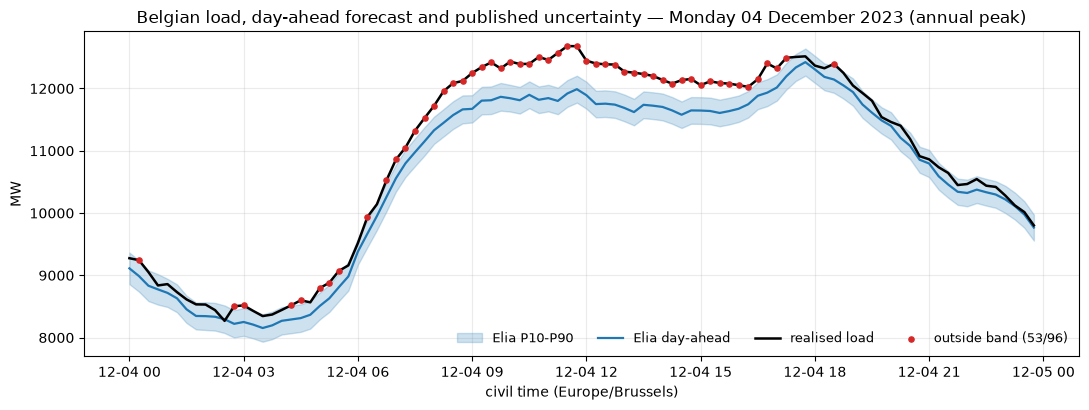

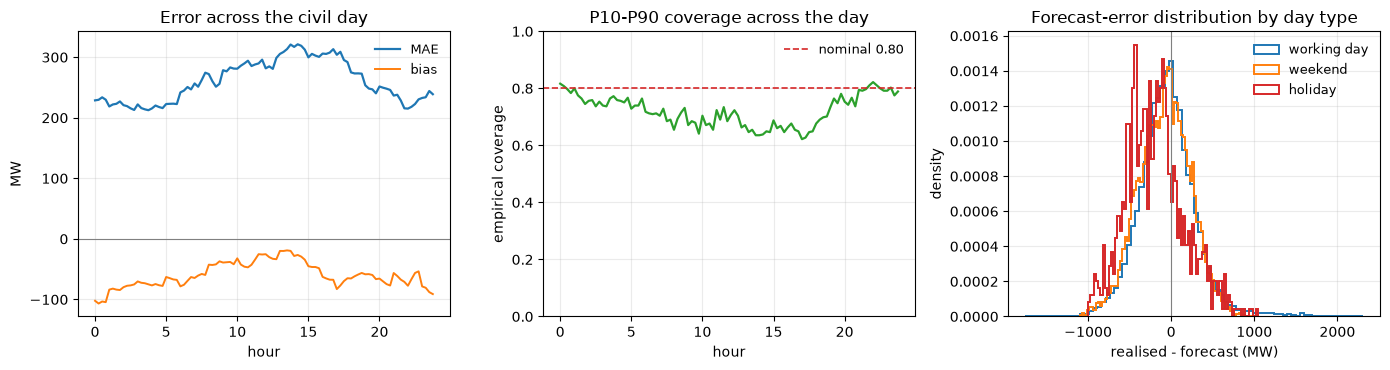

annual peak day: 2023-12-04  peak = 12,681 MW
widest band day: 2023-12-29


In [5]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 05 · §3 · First figures — is the data interesting?             v1.0.0
# provides ▸ —   ·   requires ▸ A · by_hour · plt · np · pd · TZ
# ══════════════════════════════════════════════════════════════════════════
# One day in full, then the shape of the error and the band across the day.

peak_day = A.loc[A["y"].idxmax(), "civil_date"]
d = A[A["civil_date"] == peak_day].copy()
d["t"] = d["datetime"].dt.tz_convert(TZ)

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.fill_between(d["t"], d["q10_da"], d["q90_da"], alpha=.22, color="tab:blue",
                label="Elia P10-P90")
ax.plot(d["t"], d["yhat_da"], color="tab:blue", lw=1.6, label="Elia day-ahead")
ax.plot(d["t"], d["y"], color="black", lw=1.8, label="realised load")
out = d[~d["inside"]]
ax.scatter(out["t"], out["y"], s=14, color="tab:red", zorder=5,
           label=f"outside band ({len(out)}/{len(d)})")
ax.set(title=f"Belgian load, day-ahead forecast and published uncertainty — "
             f"{peak_day:%A %d %B %Y} (annual peak)",
       xlabel=f"civil time ({TZ})", ylabel="MW")
ax.legend(frameon=False, ncol=4, fontsize=9); ax.grid(alpha=.25)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))

q = A.groupby("qod").agg(mae=("e", lambda s: s.abs().mean()),
                         bias=("e", "mean"))
axes[0].plot(q.index / 4, q["mae"], color="tab:blue", lw=1.6, label="MAE")
axes[0].plot(q.index / 4, q["bias"], color="tab:orange", lw=1.4, label="bias")
axes[0].axhline(0, color="grey", lw=.8)
axes[0].set(title="Error across the civil day", xlabel="hour", ylabel="MW")
axes[0].legend(frameon=False, fontsize=9); axes[0].grid(alpha=.25)

c = A.groupby("qod")["inside"].mean()
axes[1].plot(c.index / 4, c, color="tab:green", lw=1.6)
axes[1].axhline(.80, color="tab:red", ls="--", lw=1.2, label="nominal 0.80")
axes[1].set(title="P10-P90 coverage across the day", xlabel="hour",
            ylabel="empirical coverage", ylim=(0, 1))
axes[1].legend(frameon=False, fontsize=9); axes[1].grid(alpha=.25)

for dt, col in [("working day", "tab:blue"), ("weekend", "tab:orange"),
                ("holiday", "tab:red")]:
    s = A[A["daytype"] == dt]
    if len(s):
        axes[2].hist(s["e"], bins=80, histtype="step", density=True,
                     color=col, lw=1.4, label=dt)
axes[2].axvline(0, color="grey", lw=.8)
axes[2].set(title="Forecast-error distribution by day type", xlabel="realised - forecast (MW)",
            ylabel="density")
axes[2].legend(frameon=False, fontsize=9); axes[2].grid(alpha=.25)

plt.tight_layout(); plt.show()

print(f"annual peak day: {peak_day:%Y-%m-%d}  peak = {A['y'].max():,.0f} MW")
print(f"widest band day: {A.groupby('civil_date').apply(lambda g: (g.q90_da - g.q10_da).mean()).idxmax():%Y-%m-%d}")


In [6]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 06 · §4 · Spectral preparation — a gapless uniform grid        v1.0.0
# provides ▸ Y_LIN · Y_WK · FILLED · FS   ·   requires ▸ L · fill_short_gaps
# ══════════════════════════════════════════════════════════════════════════
# The FFT needs a uniform grid with no holes. Three realised-load slots are
# missing, so they are filled — deliberately, and twice by unrelated means, so
# that any spectral conclusion can be shown not to rest on the interpolation.
# A run longer than one hour would raise instead of being smoothed over.

FS = 96.0                                   # samples per day on the UTC axis

Y_LIN, FILLED = fill_short_gaps(L["y"].to_numpy(), max_gap=4, method="linear")
Y_WK,  _      = fill_short_gaps(L["y"].to_numpy(), max_gap=4, method="weekly")

gaps = L.loc[FILLED, ["datetime", "civil_date", "qod"]].copy()
gaps["linear"] = Y_LIN[FILLED]
gaps["weekly"] = Y_WK[FILLED]
gaps["diff_MW"] = gaps["linear"] - gaps["weekly"]

print(f"filled {int(FILLED.sum())} of {len(L)} slots "
      f"({FILLED.sum() / len(L):.4%} of the series)")
print(gaps.to_string(index=False))
print(f"\nlargest disagreement between the two fills: "
      f"{gaps['diff_MW'].abs().max():.1f} MW")
print(f"series std: {np.nanstd(L['y']):.1f} MW — the fills differ by a small "
      f"fraction of one standard deviation, on 3 of {len(L)} points")


filled 3 of 35040 slots (0.0086% of the series)
                 datetime civil_date  qod    linear  weekly  diff_MW
2023-08-10 09:00:00+00:00 2023-08-10   44  8787.545 8688.15   99.395
2023-08-11 09:00:00+00:00 2023-08-11   44  9148.695 8803.79  344.905
2023-09-11 09:00:00+00:00 2023-09-11   44 11141.125 9731.21 1409.915

largest disagreement between the two fills: 1409.9 MW
series std: 1353.1 MW — the fills differ by a small fraction of one standard deviation, on 3 of 35040 points


In [7]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 07 · §4 · Periodogram and the periods the data actually contains v1.0.0
# provides ▸ FRQ · PSD · PEAKS · REF   ·   requires ▸ Y_LIN · Y_WK · FS
# ══════════════════════════════════════════════════════════════════════════
# Peaks are located by prominence on the log spectrum. No daily or weekly
# frequency is supplied in advance, so whatever appears is what the series has.
# Two cross-checks follow the house rule that a result is certified, not
# asserted: the spectrum is recomputed on the independent weekly fill, and
# without the Hann window.

FRQ, PSD = periodogram(Y_LIN, FS)                       # detrended, Hann
PEAKS = dominant_periods(FRQ, PSD, n_peaks=12, min_period_h=1.0)

PEAKS["period"] = np.where(PEAKS["period_d"] >= 1.5,
                           PEAKS["period_d"].round(2).astype(str) + " d",
                           PEAKS["period_h"].round(2).astype(str) + " h")

def structural(df, min_share=1e-3):
    """Components carrying at least 0.1% of the resolved density. Below that
    the peaks are at noise level and nothing should be built on them."""
    return np.sort(df.loc[df["share"] >= min_share, "period_h"].to_numpy())

REF = structural(PEAKS)
print("dominant spectral components — ranked by power, periods read off after")
print(PEAKS[["freq_cpd", "period", "psd", "share"]].to_string(index=False))
print(f"\n{len(REF)} of them carry >= 0.1% of the resolved density; the rest "
      f"sit at noise level and justify nothing")

# --- cross-checks: the structure must not depend on how it was computed ----
def agrees(other, tol=0.02):
    o = structural(other)
    return bool(len(o) == len(REF) and np.all(np.isclose(o, REF, rtol=tol)))

p_wk = dominant_periods(*periodogram(Y_WK, FS), n_peaks=12, min_period_h=1.0)
p_box = dominant_periods(*periodogram(Y_LIN, FS, window=None), n_peaks=12,
                         min_period_h=1.0)
print(f"\nindependent weekly gap fill  -> same components: {agrees(p_wk)}")
print(f"no window (leakage unmitigated) -> same components: {agrees(p_box)}")

# --- what the resolution allows to be said ---------------------------------
n = len(Y_LIN)
df_cpd = FS / n                                          # bin width, cycles/day
print(f"\nfrequency resolution: {df_cpd:.5f} cycles/day  "
      f"(record length {n / FS:.0f} days)")
print(f"the daily cycle sits on bin {1.0 / df_cpd:.0f} exactly; "
      f"the weekly cycle at {1 / 7 / df_cpd:.2f} does not — it falls between "
      f"bins and its power is spread over neighbours")
print(f"anything slower than {1 / df_cpd:.0f} days, the annual cycle included, "
      f"is unresolvable in a one-year record and is absorbed by the detrending")


dominant spectral components — ranked by power, periods read off after
 freq_cpd  period          psd    share
 1.000000  24.0 h 1.189207e+08 0.232127
 0.142466  7.02 d 3.639269e+07 0.071037
 2.000000  12.0 h 2.804351e+07 0.054739
 0.013699  73.0 d 1.502581e+07 0.029330
 0.284932  3.51 d 9.951685e+06 0.019425
 0.857534 27.99 h 3.399593e+06 0.006636
 0.715068 33.56 h 2.228216e+06 0.004349
 0.049315 20.28 d 1.928464e+06 0.003764
 0.030137 33.18 d 1.909773e+06 0.003728
 1.142466 21.01 h 1.726904e+06 0.003371
 0.065753 15.21 d 1.499809e+06 0.002928
 0.991781  24.2 h 7.765599e+05 0.001516

12 of them carry >= 0.1% of the resolved density; the rest sit at noise level and justify nothing

independent weekly gap fill  -> same components: True
no window (leakage unmitigated) -> same components: False

frequency resolution: 0.00274 cycles/day  (record length 365 days)
the daily cycle sits on bin 365 exactly; the weekly cycle at 52.14 does not — it falls between bins and its power is spread over 

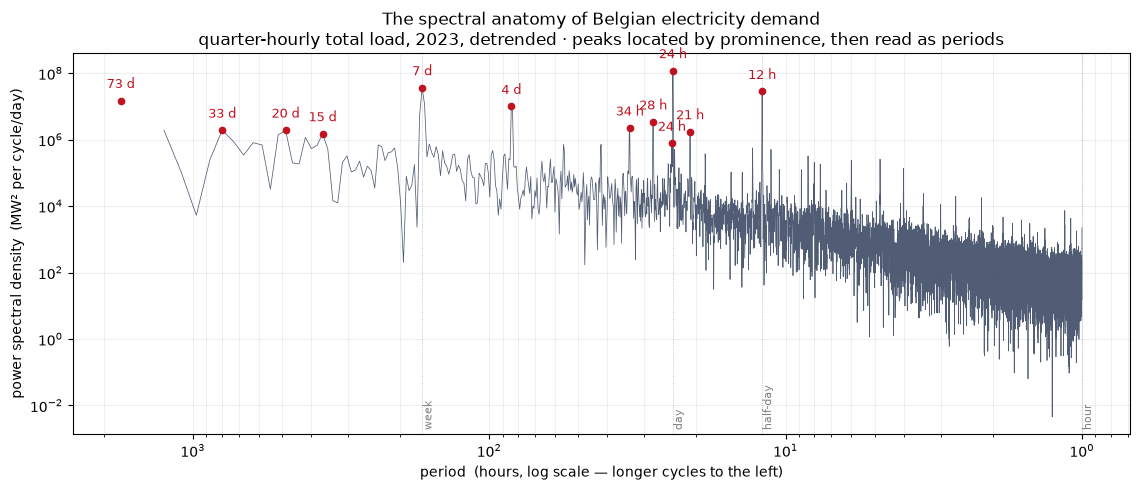

12 structural components carry 43.3% of the density in the resolved band


In [8]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 08 · §4 · Figure — the spectral anatomy of Belgian demand      v1.0.0
# provides ▸ —   ·   requires ▸ FRQ · PSD · PEAKS · plt
# ══════════════════════════════════════════════════════════════════════════
per_h = np.divide(24.0, FRQ, out=np.full_like(FRQ, np.inf), where=FRQ > 0)
m = (per_h >= 1.0) & (per_h <= 24 * 60)

fig, ax = plt.subplots(figsize=(11.5, 5.0))
ax.plot(per_h[m], PSD[m], lw=.55, color="#33415c", alpha=.85)
ax.set_xscale("log"); ax.set_yscale("log")
ax.invert_xaxis()                                   # long cycles on the left

for _, r in PEAKS[PEAKS["share"] >= 1e-3].iterrows():
    ax.plot(r["period_h"], r["psd"], "o", ms=4.5, color="#c1121f", zorder=5)
    lab = (f"{r['period_d']:.0f} d" if r["period_d"] >= 1.5
           else f"{r['period_h']:.0f} h")
    ax.annotate(lab, (r["period_h"], r["psd"]), textcoords="offset points",
                xytext=(0, 9), ha="center", fontsize=9, color="#c1121f")

for p, lab in [(24 * 7, "week"), (24, "day"), (12, "half-day"), (1, "hour")]:
    ax.axvline(p, color="grey", lw=.6, ls=":", alpha=.6)
    ax.text(p, ax.get_ylim()[0], f" {lab}", rotation=90, va="bottom",
            fontsize=8, color="grey")

ax.set(xlabel="period  (hours, log scale — longer cycles to the left)",
       ylabel="power spectral density  (MW² per cycle/day)",
       title="The spectral anatomy of Belgian electricity demand\n"
             "quarter-hourly total load, 2023, detrended · peaks located by "
             "prominence, then read as periods")
ax.grid(alpha=.2, which="both")
plt.tight_layout()
plt.savefig("../figures/spectral_anatomy.png", dpi=200, bbox_inches="tight")
plt.show()

carried = PEAKS.loc[PEAKS["share"] >= 1e-3, "share"].sum()
print(f"{int((PEAKS['share'] >= 1e-3).sum())} structural components carry "
      f"{carried:.1%} of the density in the resolved band")


### 4. What the spectrum does and does not license

The periodogram is a variance decomposition, not a statement about
predictability. A sharp peak says that a periodic component explains a large
share of the *historical* variance; it does not say that a model built on that
component will forecast well out of sample. Three specific limits apply here.

**Resolution.** One year of quarter-hourly data gives a bin width of 1/365
cycles per day. The daily cycle and its harmonics land on bin centres exactly;
the weekly cycle does not, because 365/7 is not an integer, so its power is
spread across neighbouring bins and its apparent amplitude is understated. The
annual cycle cannot be resolved at all from a single year — it is one period
of the record, indistinguishable from the trend that detrending removes. Any
seasonal effect therefore has to enter a forecasting model through calendar
terms, not through the spectrum.

**Civil time versus physical time.** The transform runs on the UTC axis, which
is uniform in physical time. Human demand follows the Belgian civil clock,
which shifts by an hour twice a year. The daily peak is consequently smeared
by a small amount that no windowing can remove; it is a property of the
phenomenon, not of the estimator.

**Stationarity.** A periodogram over a full year assumes the periodic structure
is stable across it. Belgian load is not: the shape of a January weekday and a
July weekday differ in amplitude and in timing. The spectrum reports the
average structure and will therefore justify a *starting* set of harmonics, not
a final one.

What the spectrum does license is a short, defensible list of frequencies for
transparent Fourier terms, chosen from the data rather than from convention,
together with the honest expectation that periodicity alone will not carry a
day-ahead forecast. Whether it does is the question the next increment tests
against seasonal-naive benchmarks — and a negative answer there is a result,
not a failure.
